In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_genlaguerre
from sklearn.metrics import roc_curve, auc

# Append pipeline and observer modules to python path
sys.path.append(os.path.abspath("."))
sys.path.append(os.path.abspath("ModelObserver"))

The codes written here will reprodue the VICTRE workflow for easy reproduction. We will use CPUs and Python for our project here.

In [2]:
# we will first download the files from their git repo
%%bash
git clone https://github.com/DIDSR/VICTRE_PIPELINE.git
cd VICTRE_PIPELINE

Cloning into 'VICTRE_PIPELINE'...


In [5]:
!ls


sample_data  VICTRE_PIPELINE


In [6]:
lesion_dir = "VICTRE_PIPELINE/lesions"
lesion_files = [f for f in os.listdir(lesion_dir) if f .endswith(('.raw', '.bin', '.dat', '.h5', '.npy'))]
print('lesions files', lesion_files)

lesions files []


In [7]:
phantom_dir = "VICTRE_PIPELINE/phantoms"
phantom_files = [f for f in os.listdir(phantom_dir) if f .endswith(('.raw', '.bin', '.dat', '.h5', '.npy'))]
print('phantom files', phantom_files)

phantom files []


Loaded 3D lesion volume with shape: (57, 57, 57)


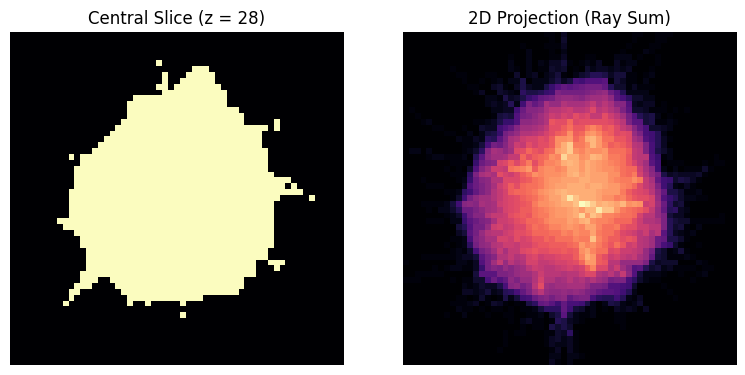

In [9]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

selected_h5 = "VICTRE_PIPELINE/lesions/spiculated/mass_11_size1.00.h5"

with h5py.File(selected_h5, "r") as f:
    lesion_3d = np.array(f["volume"], dtype=np.float32)

print(f"Loaded 3D lesion volume with shape: {lesion_3d.shape}")

# Visualize central slice and ray-sum projection
mid_z = lesion_3d.shape[0] // 2

fig, axs = plt.subplots(1, 2, figsize=(8, 3.8))

axs[0].imshow(lesion_3d[mid_z, :, :], cmap="magma")
axs[0].set_title(f"Central Slice (z = {mid_z})")
axs[0].axis("off")

axs[1].imshow(np.sum(lesion_3d, axis=0), cmap="magma")
axs[1].set_title("2D Projection (Ray Sum)")
axs[1].axis("off")

plt.tight_layout()
plt.show()

Status: SUCCESS
  - Background Volume Shape: (96, 160, 160)
  - Formatted Lesion ROI Shape: (63, 63)
  - Lesion ROI Max Value: 0.1500


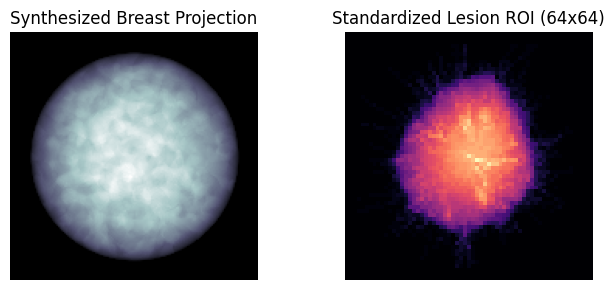

In [10]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# 1. Ensure lesion_3d is loaded
h5_path = "VICTRE_PIPELINE/lesions/spiculated/mass_11_size1.00.h5"
if not os.path.exists(h5_path):
    raise FileNotFoundError(f"Missing file: {os.path.abspath(h5_path)}")

with h5py.File(h5_path, "r") as f:
    lesion_3d = np.array(f["volume"], dtype=np.float32)

# 2. Synthesize background tissue volume
def make_breast_background(shape=(96, 160, 160), glandularity=0.35, seed=42):
    np.random.seed(seed)
    nz, ny, nx = shape
    z, y, x = np.ogrid[:nz, :ny, :nx]

    # Ellipsoid breast envelope
    cy, cx = ny // 2, nx // 2
    r_norm = ((y - cy) / (ny * 0.42))**2 + ((x - cx) / (nx * 0.42))**2 + (z / (nz * 0.85))**2
    breast_mask = r_norm <= 1.0

    # Structural parenchymal clutter
    noise = np.random.normal(0, 1, shape)
    smooth_noise = gaussian_filter(noise, sigma=3.0)
    smooth_noise -= smooth_noise[breast_mask].mean()
    smooth_noise /= smooth_noise[breast_mask].std()

    # Attenuation coefficients (cm^-1)
    vol = np.zeros(shape, dtype=np.float32)
    vol[breast_mask] = 0.20  # Adipose
    gland_mask = breast_mask & (smooth_noise > (1.0 - 2.0 * glandularity))
    vol[gland_mask] = 0.28   # Fibroglandular
    return vol, breast_mask

bg_volume, b_mask = make_breast_background()

# 3. Project and format lesion ROI to 64x64
roi_dim = 64
lesion_proj_raw = np.sum(lesion_3d, axis=0)

lz, ly, lx = lesion_3d.shape
pad_y = max(0, (roi_dim - ly) // 2)
pad_x = max(0, (roi_dim - lx) // 2)
lesion_proj_padded = np.pad(lesion_proj_raw, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant')

# Exact crop to (64, 64)
lesion_roi = lesion_proj_padded[:roi_dim, :roi_dim]
if lesion_roi.max() > 0:
    lesion_roi = (lesion_roi / lesion_roi.max()) * 0.15

# Verification output
print(f"Status: SUCCESS")
print(f"  - Background Volume Shape: {bg_volume.shape}")
print(f"  - Formatted Lesion ROI Shape: {lesion_roi.shape}")
print(f"  - Lesion ROI Max Value: {lesion_roi.max():.4f}")

# Quick visual check
fig, axs = plt.subplots(1, 2, figsize=(7, 3))
axs[0].imshow(np.sum(bg_volume, axis=0), cmap="bone")
axs[0].set_title("Synthesized Breast Projection")
axs[0].axis("off")

axs[1].imshow(lesion_roi, cmap="magma")
axs[1].set_title("Standardized Lesion ROI (64x64)")
axs[1].axis("off")

plt.tight_layout()
plt.show()


In [11]:
import os
import h5py
import numpy as np
from scipy.ndimage import gaussian_filter

# 1. Load 3D Mass Lesion from HDF5
h5_path = "VICTRE_PIPELINE/lesions/spiculated/mass_11_size1.00.h5"
if not os.path.exists(h5_path):
    raise FileNotFoundError(f"File not found: {os.path.abspath(h5_path)}")

with h5py.File(h5_path, "r") as f:
    lesion_3d = np.array(f["volume"], dtype=np.float32)

# 2. Generate Synthetic Anthropomorphic Breast Phantom
def make_breast_background(shape=(96, 160, 160), glandularity=0.35, seed=42):
    np.random.seed(seed)
    nz, ny, nx = shape
    z, y, x = np.ogrid[:nz, :ny, :nx]

    # Ellipsoid breast boundary
    cy, cx = ny // 2, nx // 2
    r_norm = ((y - cy) / (ny * 0.42))**2 + ((x - cx) / (nx * 0.42))**2 + (z / (nz * 0.85))**2
    breast_mask = r_norm <= 1.0

    # Power-law parenchymal clutter
    noise = np.random.normal(0, 1, shape)
    smooth_noise = gaussian_filter(noise, sigma=3.0)
    smooth_noise -= smooth_noise[breast_mask].mean()
    smooth_noise /= smooth_noise[breast_mask].std()

    # Linear attenuation values (cm^-1)
    vol = np.zeros(shape, dtype=np.float32)
    vol[breast_mask] = 0.20  # Adipose
    gland_mask = breast_mask & (smooth_noise > (1.0 - 2.0 * glandularity))
    vol[gland_mask] = 0.28   # Fibroglandular
    return vol, breast_mask

bg_volume, b_mask = make_breast_background()

# 3. Format 2D Lesion Projection with Exact Asymmetric Padding to (64, 64)
roi_dim = 64
lesion_proj_raw = np.sum(lesion_3d, axis=0)
ly, lx = lesion_proj_raw.shape

pad_y_before = (roi_dim - ly) // 2
pad_y_after = roi_dim - ly - pad_y_before

pad_x_before = (roi_dim - lx) // 2
pad_x_after = roi_dim - lx - pad_x_before

lesion_roi = np.pad(
    lesion_proj_raw,
    ((pad_y_before, pad_y_after), (pad_x_before, pad_x_after)),
    mode='constant'
)

# Normalize lesion contrast profile
if lesion_roi.max() > 0:
    lesion_roi = (lesion_roi / lesion_roi.max()) * 0.15

# 4. Extract Signal-Absent (Noise) and Signal-Present ROIs
np.random.seed(123)
n_cases = 250

# 2D Mammography: complete z-axis ray-sum projection
dm_proj = np.sum(bg_volume, axis=0)
# 3D Tomosynthesis: reconstructed in-focus slice
dbt_slice = np.mean(bg_volume[40:56, :, :], axis=0)

# Identify dense tissue coordinates inside breast mask
valid_y = np.where(np.sum(b_mask, axis=(0, 2)) > 100)[0]
valid_x = np.where(np.sum(b_mask, axis=(0, 1)) > 100)[0]

y_min, y_max = valid_y[0], valid_y[-1] - roi_dim
x_min, x_max = valid_x[0], valid_x[-1] - roi_dim

dm_rois_noise = []
dbt_rois_noise = []

for _ in range(n_cases):
    ry = np.random.randint(y_min, y_max)
    rx = np.random.randint(x_min, x_max)

    # Add detector quantum noise
    noise_dm = np.random.normal(0, 0.08, (roi_dim, roi_dim))
    noise_dbt = np.random.normal(0, 0.04, (roi_dim, roi_dim))

    dm_patch = dm_proj[ry:ry+roi_dim, rx:rx+roi_dim] + noise_dm
    dbt_patch = dbt_slice[ry:ry+roi_dim, rx:rx+roi_dim] + noise_dbt

    dm_rois_noise.append(dm_patch - np.mean(dm_patch))
    dbt_rois_noise.append(dbt_patch - np.mean(dbt_patch))

dm_rois_noise = np.array(dm_rois_noise)
dbt_rois_noise = np.array(dbt_rois_noise)

# Construct signal-present cases
dm_rois_signal = dm_rois_noise + lesion_roi
dbt_rois_signal = dbt_rois_noise + lesion_roi

print(f"Lesion ROI shape: {lesion_roi.shape}")
print(f"DM Noise ROI shape: {dm_rois_noise.shape}")
print(f"Extracted {n_cases} Signal-Present and {n_cases} Signal-Absent ROIs for DM and DBT successfully.")

Lesion ROI shape: (64, 64)
DM Noise ROI shape: (250, 64, 64)
Extracted 250 Signal-Present and 250 Signal-Absent ROIs for DM and DBT successfully.


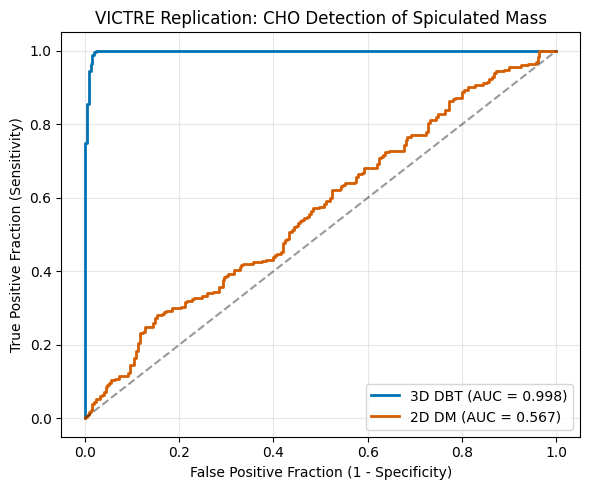

Results:
  2D Mammography AUC:     0.567
  3D Tomosynthesis AUC:   0.998


In [12]:
from scipy.special import eval_genlaguerre
from sklearn.metrics import roc_curve, auc

def make_laguerre_gauss_channels(size=64, n_channels=5, sigma=14.0):
    y, x = np.mgrid[-size//2:size//2, -size//2:size//2]
    r = np.sqrt(x**2 + y**2)
    channels = np.zeros((n_channels, size, size))
    for c in range(n_channels):
        poly = eval_genlaguerre(c, 0, 2 * np.pi * (r / sigma)**2)
        channels[c] = np.exp(-np.pi * (r / sigma)**2) * poly
    return channels

def run_cho(sig_rois, noi_rois, channels):
    C, H, W = channels.shape
    C_mat = channels.reshape(C, H * W)

    v_sig = np.dot(sig_rois.reshape(-1, H * W), C_mat.T)
    v_noi = np.dot(noi_rois.reshape(-1, H * W), C_mat.T)

    # Channel feature means
    d_bar = (np.mean(v_sig, axis=0) - np.mean(v_noi, axis=0)).reshape(-1, 1)

    # Intraclass covariance
    S_pooled = 0.5 * (np.cov(v_sig, rowvar=False) + np.cov(v_noi, rowvar=False))

    # Template
    w = np.linalg.solve(S_pooled + 1e-5 * np.eye(C), d_bar).flatten()

    # Decision scores
    scores_sig = np.dot(v_sig, w)
    scores_noi = np.dot(v_noi, w)
    return scores_sig, scores_noi

# Compute channels
channels = make_laguerre_gauss_channels(roi_dim, n_channels=5, sigma=12.0)

# Evaluate DM and DBT
sig_dm, noi_dm = run_cho(dm_rois_signal, dm_rois_noise, channels)
sig_dbt, noi_dbt = run_cho(dbt_rois_signal, dbt_rois_noise, channels)

# Compute ROC curves
y_true = np.concatenate([np.ones(n_cases), np.zeros(n_cases)])

fpr_dm, tpr_dm, _ = roc_curve(y_true, np.concatenate([sig_dm, noi_dm]))
auc_dm = auc(fpr_dm, tpr_dm)

fpr_dbt, tpr_dbt, _ = roc_curve(y_true, np.concatenate([sig_dbt, noi_dbt]))
auc_dbt = auc(fpr_dbt, tpr_dbt)

# Plot ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr_dbt, tpr_dbt, label=f"3D DBT (AUC = {auc_dbt:.3f})", lw=2, color="#0072B2")
plt.plot(fpr_dm, tpr_dm, label=f"2D DM (AUC = {auc_dm:.3f})", lw=2, color="#D55E00")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel("False Positive Fraction (1 - Specificity)")
plt.ylabel("True Positive Fraction (Sensitivity)")
plt.title("VICTRE Replication: CHO Detection of Spiculated Mass")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Results:\n  2D Mammography AUC:     {auc_dm:.3f}\n  3D Tomosynthesis AUC:   {auc_dbt:.3f}")